In [1]:
import numpy as np 
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

### Load the Dataset

In [2]:
df = pd.read_csv("dataset.csv")

In [35]:
df.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,log_amount,hour,day,is_large,tx_count_sender,avg_amount_sender,amount_ratio
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0,9.194276,1,0,0,1,9839.64,1.0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,7.531166,1,0,0,1,1864.28,1.0
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0,5.204007,1,0,0,1,181.00,1.0
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0,5.204007,1,0,0,1,181.00,1.0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0,9.364703,1,0,0,1,11668.14,1.0


# Feature Engineering

In [3]:
# Droping the leakage columns
df = df.drop(columns=["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"])

In [4]:
# Now doing some featuer construction using pandas
df["log_amount"] = np.log1p(df["amount"])
df["hour"] = df["step"] % 24
df["day"] = df["step"] // 24
df["is_large"] = (df["amount"] > 200000).astype(int)

In [5]:
# Example of user behavior (needs groupby)
df["tx_count_sender"] = df.groupby("nameOrig")["amount"].transform("count")
df["avg_amount_sender"] = df.groupby("nameOrig")["amount"].transform("mean")
df["amount_ratio"] = df["amount"] / (df["avg_amount_sender"] + 1e-6)

In [6]:
X = df.drop(columns=["isFraud", "nameOrig", "nameDest"])  # drop IDs
y = df["isFraud"]

In [7]:
# Preprocessing pipeline
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Model Training and Evaluation

In [8]:
# Importing Models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5090096, 11)
Test shape: (1272524, 11)


### Logistic Regresson

In [10]:
model_lr = LogisticRegression(max_iter=1000)

pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),  # your ColumnTransformer
    ("classifier", model_lr)
])

In [11]:
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['step', 'amount',
                                                   'isFlaggedFraud',
                                                   'log_amount', 'hour', 'day',
                                                   'tx_count_sender',
                                                   'avg_amount_sender',
                                                   'amount_ratio']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [12]:
y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

In [13]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
print("LR Accuracy:", round(acc_lr,4))

LR Accuracy: 0.9987


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=skf, scoring='roc_auc')

print("5-Fold CV ROC-AUC scores:", np.round(cv_scores_lr,4))
print("Mean CV ROC-AUC:", round(cv_scores_lr.mean(),4))


5-Fold CV ROC-AUC scores: [0.9179 0.8947 0.9132 0.9116 0.9073]
Mean CV ROC-AUC: 0.9089


In [15]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)


Confusion Matrix:
 [[1270876       5]
 [   1642       1]]


In [16]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred_lr, digits=4))


Classification Report:
               precision    recall  f1-score   support

           0     0.9987    1.0000    0.9994   1270881
           1     0.1667    0.0006    0.0012      1643

    accuracy                         0.9987   1272524
   macro avg     0.5827    0.5003    0.5003   1272524
weighted avg     0.9976    0.9987    0.9981   1272524



In [17]:
from sklearn.metrics import roc_auc_score

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
print("ROC-AUC:", round(roc_auc_lr,4))


ROC-AUC: 0.9091


### Random Forest

In [18]:
rf = RandomForestClassifier( n_estimators=100,
    max_depth=15,   
    max_features='sqrt',
    n_jobs=-1,     
    random_state=42)

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),  # your ColumnTransformer
    ("classifier", rf)
])

print("Pipeline created for Random Forest.")


Pipeline created for Random Forest.


In [19]:
pipe_rf.fit(X_train, y_train)
print("RF model trained successfully.")

RF model trained successfully.


In [20]:
y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

print("Predictions completed for RF")

Predictions completed for RF


In [21]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(acc_rf,4))

Random Forest Accuracy: 0.9991


In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=skf, scoring='roc_auc')

print("5-Fold CV ROC-AUC scores:", np.round(cv_scores_rf,4))
print("Mean CV ROC-AUC:", round(cv_scores_rf.mean(),4))

5-Fold CV ROC-AUC scores: [0.9714 0.9699 0.9729 0.9706 0.9728]
Mean CV ROC-AUC: 0.9715


In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:\n", cm_rf)

Random Forest Confusion Matrix:
 [[1270846      35]
 [   1093     550]]


In [24]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0     0.9991    1.0000    0.9996   1270881
           1     0.9402    0.3348    0.4937      1643

    accuracy                         0.9991   1272524
   macro avg     0.9697    0.6674    0.7466   1272524
weighted avg     0.9991    0.9991    0.9989   1272524



In [25]:
from sklearn.metrics import roc_auc_score

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print("Random Forest ROC-AUC:", round(roc_auc_rf,4))

Random Forest ROC-AUC: 0.9705


### XGBoost

In [26]:
xgb = XGBClassifier(
    n_estimators=100,       # reduce number of trees for speed
    max_depth=8,            # limit depth to reduce computation
    learning_rate=0.1,      # default, can tune later
    tree_method='hist',     # histogram-based, much faster on large data
    subsample=0.8,          # row sampling to speed up
    colsample_bytree=0.8,   # feature sampling to speed up
    n_jobs=-1,              # use all CPU cores
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'   # required to avoid warning
    )

pipe_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),  # your ColumnTransformer
    ("classifier", xgb)
])

print("Pipeline created for XGBoost.")

Pipeline created for XGBoost.


In [27]:
pipe_xgb.fit(X_train, y_train)
print("XGBoost model trained successfully.")

c:\Users\Deadpool\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:01:40] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost model trained successfully.


In [28]:
y_pred_xgb = pipe_xgb.predict(X_test)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print("Predictions completed for XGBoost.")

Predictions completed for XGBoost.


In [29]:
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", round(acc_xgb,4))

XGBoost Accuracy: 0.9992


In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=skf, scoring='roc_auc')

print("5-Fold CV ROC-AUC scores:", np.round(cv_scores_xgb,4))
print("Mean CV ROC-AUC:", round(cv_scores_xgb.mean(),4))

c:\Users\Deadpool\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:01] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Deadpool\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:18] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Deadpool\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:35] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Deadpool\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:52] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Dea

5-Fold CV ROC-AUC scores: [0.9735 0.9708 0.9744 0.9733 0.974 ]
Mean CV ROC-AUC: 0.9732


In [31]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("XGBoost Confusion Matrix:\n", cm_xgb)

XGBoost Confusion Matrix:
 [[1270831      50]
 [    953     690]]


In [32]:
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb, digits=4))

XGBoost Classification Report:
               precision    recall  f1-score   support

           0     0.9993    1.0000    0.9996   1270881
           1     0.9324    0.4200    0.5791      1643

    accuracy                         0.9992   1272524
   macro avg     0.9658    0.7100    0.7894   1272524
weighted avg     0.9992    0.9992    0.9991   1272524



In [33]:
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("XGBoost ROC-AUC:", round(roc_auc_xgb,4))

XGBoost ROC-AUC: 0.9728


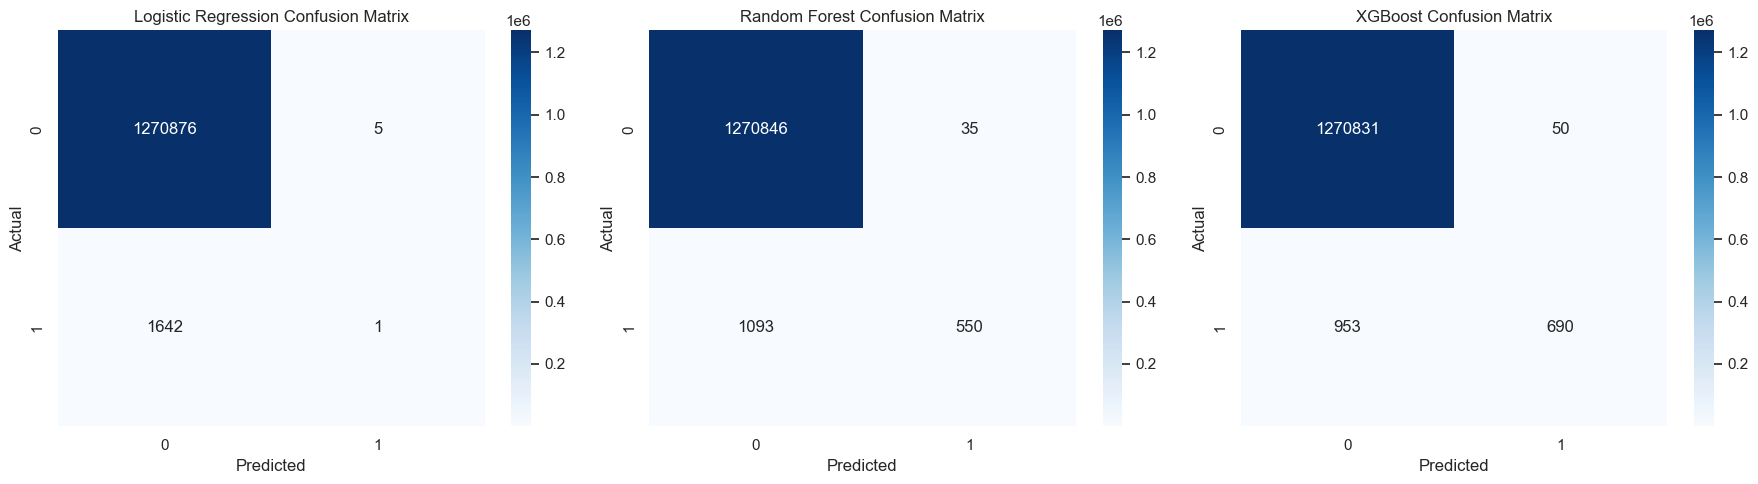

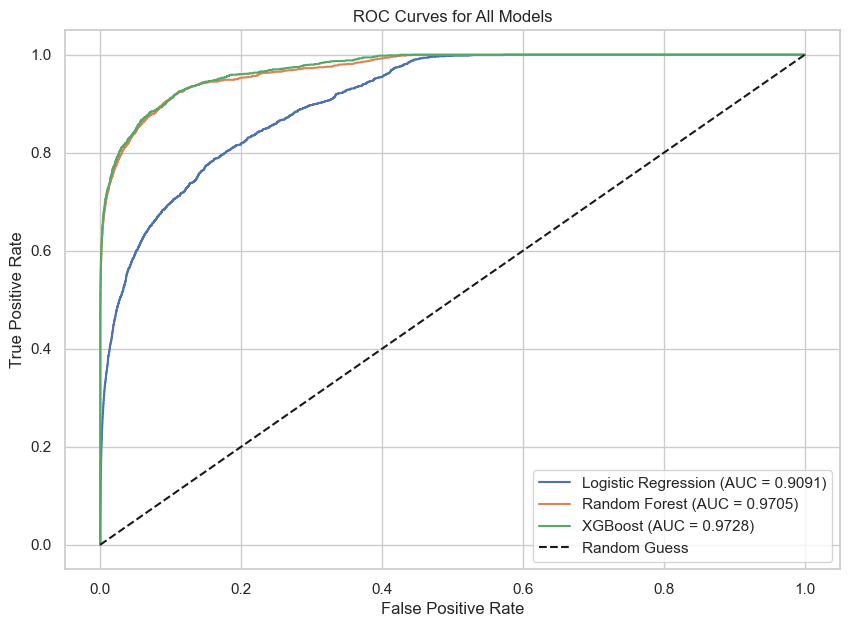

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

sns.set(style="whitegrid")

# --- 1. Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models_cm = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for ax, (name, y_pred) in zip(axes, models_cm.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# --- 2. ROC Curves ---
plt.figure(figsize=(10,7))

models_roc = {
    "Logistic Regression": y_proba_lr,
    "Random Forest": y_proba_rf,
    "XGBoost": y_proba_xgb
}

for name, y_proba in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
